In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt; plt.style.use("dark_background")
import seaborn as sns
import sys; sys.path.append("/data/jerrylee/pjt/BIGFAM.v.0.1")
from BIGFAM import obj2, tools
from tqdm import tqdm
import statsmodels.formula.api as smf
from scipy.optimize import minimize

In [2]:
def _matchType(df_frreg):
    df_frreg = df_frreg.astype({"DOR": int,
                                "rel_type": str,
                                "sex_type": str,
                                "slope": float,
                                "se_slope": float,
                                "rx": float,
                                "n": int})
    return df_frreg

def _make_simul_reg(A, X, S, ra, rx, rs, n=1, noise_sd=0.01):
    """Make FR-reg coefficient."""
    by_A = ra * A
    by_X = rx * X
    by_S = rs * S
    by_E = np.random.normal(0, noise_sd, n)
    
    coef = by_A + by_X + by_S + by_E
    
    if len(coef) == 1:
        coef = coef[0]
        
    return coef

def _resamplingFRregCoefficients(df_lmbds, n_resample=100, n_block=10):
    """
    df_lmbds : summary of FR-reg
    """
    df_block = pd.DataFrame()

    for rel_type in df_lmbds["rel_type"].unique():
        df_rel = df_lmbds[df_lmbds["rel_type"] == rel_type].copy()
        dor, rel_type, sex_type, rx, slope, se_slope = df_rel.iloc[0].values

        resampled_slopes = np.random.normal(slope, se_slope, (n_block, n_resample // n_block))
        resampled_slopes = resampled_slopes.flatten()

        df_tmp = pd.DataFrame({
            "DOR": dor,
            "rel_type": rel_type,
            "sex_type": sex_type,
            "rx": rx,
            "slope": resampled_slopes,
            "block": np.repeat(np.arange(n_block), n_resample // n_block),
        })

        df_block = pd.concat([df_block, df_tmp], ignore_index=True)

    return df_block

def _regressOutMean(df_block):
    df_res = df_block.copy()
    # etas = {}

    def regress_out_mean(group):
        ll = smf.ols(formula="slope ~ 1", data=group).fit()
        # etas[group["DOR"].iloc[0]] = 2**group["DOR"].iloc[0] * ll.params["Intercept"]
        group["eta"] = 2**group["DOR"].iloc[0] * ll.params["Intercept"]
        group["residual"] = ll.resid
        group["tl"] = group["rx"] - group["rx"].mean()
        return group

    df_res = df_res.groupby(["block", "DOR"]).apply(regress_out_mean)

    return df_res

def _lossFuncX(x, df, alpha):
    # Fidelity term
    loss_fid = np.sum((df["residual"] - df["tl"] * x) ** 2)

    # L2 term
    loss_l2 = alpha * (x ** 2)

    return loss_fid + loss_l2

def _optToFindX(df_block, alpha):
    x0 = [0.01]
    bounds = [(-1, 1)]

    model = minimize(
        fun=_lossFuncX,
        x0=x0,
        args=(df_block, alpha),
        bounds=bounds,
        tol=1e-6
    )

    return model

# Step 1. ridge vs. no-ridge

In [3]:
# load reference familial relationships
root_path = "/data/jerrylee/pjt/BIGFAM"
df_frreg = pd.read_csv(f"{root_path}/data/frreg/Weight.REL.lmbd", 
                       delim_whitespace=True)
df_frreg = obj2._matchType(df_frreg)

relations = df_frreg[["DOR", "rel_type", "sex_type", "rx"]]

In [15]:
# ridge vs. no ridge
As = [0.1, 0.2, 0.4, 0.6] #[0.6, 0.4, 0.2]
Ss = [0.2, 0.1, 0.05] # DOR1, DOR2, DOR3
se_frreg = 5e-3

alps = [-4, -3, -2, -1, 0, 1, 2,]
# alps = [-1]
n_resample = 1
n_block = 1

In [17]:
res_cols = ["A_true", "X_true", 
            "eta", "alp", 
            "X_ridge", "X_noRidge"]
df_res = pd.DataFrame(columns=res_cols)

for A in As:
    X = A / 20 
    
    # 100 different shared environmental situations
    for idx_s in tqdm(range(100)): 
        
        # simulate FR-reg coefficients
        df_lmbds = pd.DataFrame(columns=["DOR", "rel_type", "sex_type", "rx", "slope", "se_slope"])
        
        for _, row in relations.iterrows():
            
            # set true parameters
            dor, rel_type, sex_type, rx = row.values
            ra = 0.5**dor
            rs = np.random.normal(0.5, 0.1)
            # rs = np.random.uniform(0, 1)
            S = Ss[dor-1]
            
            lmbd = _make_simul_reg(A, X, S, ra, rx, rs, n=1, noise_sd=0)
            
            df_lmbds.loc[len(df_lmbds)] = [dor, rel_type, sex_type, rx, lmbd, se_frreg]
        
        # resampling for block-jackkinfe
        df_block = _resamplingFRregCoefficients(df_lmbds, n_resample, n_block)
        
        # regress out mean
        df_block = _regressOutMean(df_block)
        
        # estimate X with SE using resampled FR-reg coefficients
        for ib in range(n_block):
            cv_block = df_block[df_block["block"] == ib]
            
            # NO RIDGE
            ll_no_ridege = (smf.ols(formula="residual ~ 0 + tl",
                                    data=cv_block)
                            .fit())
            
            # RIDGE
            mean_eta = cv_block["eta"].mean()
            for alp in alps:
                alpha = (mean_eta**alp) / cv_block.shape[0]
                
                MODEL = _optToFindX(cv_block, alpha)
                df_res.loc[len(df_res)] \
                    = [A, X, mean_eta, alp, MODEL.x[0], ll_no_ridege.params["tl"]]
    break
                

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:15<00:00,  6.51it/s]


In [18]:
alp = -2

for_plot = df_res[df_res["alp"] == alp]
xtrues = sorted(for_plot["X_true"].unique(), reverse=True)

for x_true in xtrues:
    tmp = for_plot[for_plot["X_true"] == x_true]
    print(f"{x_true:.3f}=========")
    med_nr = np.mean(tmp["X_noRidge"])
    lower_nr = np.percentile(tmp["X_noRidge"], 2.5)
    upper_nr = np.percentile(tmp["X_noRidge"], 97.5)
    med_r = np.mean(tmp["X_ridge"])
    lower_r = np.percentile(tmp["X_ridge"], 2.5)
    upper_r = np.percentile(tmp["X_ridge"], 97.5)
    
    print("No Ridge : {med:.4f}({lower:.4f}, {upper:.4f})".
          format(med = med_nr,
                 lower = lower_nr,
                 upper = upper_nr
                 ))
    print("Ridge : {med:.4f}({lower:.4f}, {upper:.4f})".
          format(med = med_r,
                 lower = lower_r, 
                 upper = upper_r
                 ))
    percent_shrink = 1 - ((upper_r - lower_r) / (upper_nr - lower_nr))
    percent_shrink = percent_shrink * 100
    print(f"{percent_shrink:.3f}% CIs shrink")

0.030=========
No Ridge : 0.0338(-0.0079, 0.0830)
Ridge : 0.0310(-0.0073, 0.0761)
8.318% CIs shrink
0.020=========
No Ridge : 0.0202(-0.0334, 0.0612)
Ridge : 0.0173(-0.0288, 0.0526)
13.966% CIs shrink
0.010=========
No Ridge : 0.0095(-0.0403, 0.0564)
Ridge : 0.0070(-0.0287, 0.0409)
27.947% CIs shrink
0.005=========
No Ridge : 0.0041(-0.0468, 0.0553)
Ridge : 0.0024(-0.0270, 0.0320)
42.176% CIs shrink


In [ ]:
df_res.to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/simulation/X/simulation.ridge_vs_no.tsv",
    sep='\t',
    index=False)

## Step 1.1 plot

In [19]:
df_res = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/simulation/X/simulation.ridge_vs_no.tsv",
    sep="\t",
)
df_res.head()

,A_true,X_true,eta,alp,X_ridge,X_noRidge
0,0.1,0.005,0.310605,-4.0,0.001418,0.011239
1,0.1,0.005,0.310605,-3.0,0.003567,0.011239
2,0.1,0.005,0.310605,-2.0,0.006738,0.011239
3,0.1,0.005,0.310605,-1.0,0.008821,0.011239
4,0.1,0.005,0.310605,0.0,0.010839,0.011239


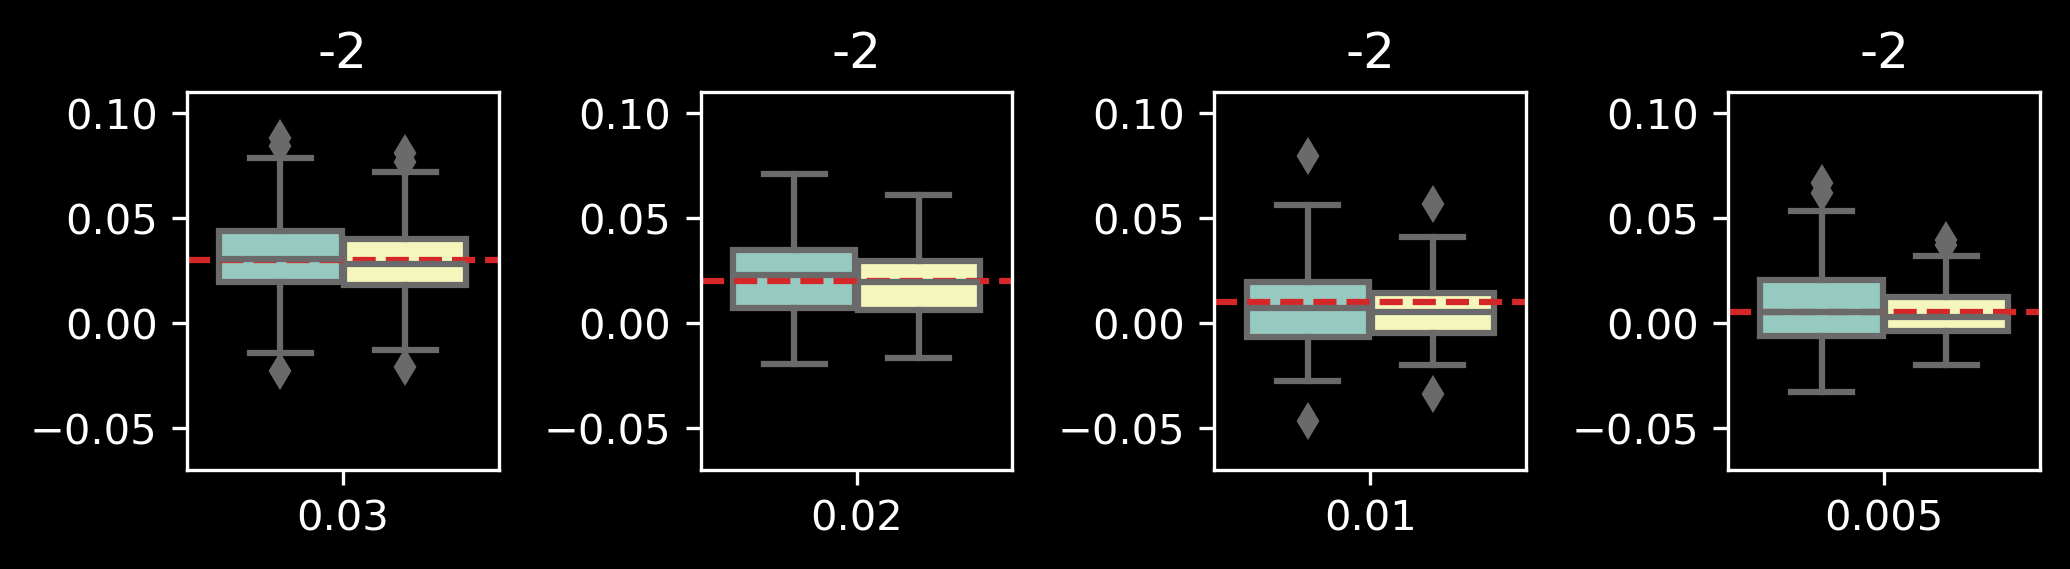

In [20]:
xtrues = sorted(df_res["X_true"].unique(), reverse=True)
alp = -2
fig, axs = plt.subplots(1, len(xtrues), figsize=(7, 2), dpi=300)

for ci, X_true in enumerate(xtrues):
    ax = axs[ci]
    
    tmp_plot = df_res[(df_res["alp"] == alp) & (df_res["X_true"] == X_true)]
    tmp_plot = pd.melt(tmp_plot[["X_true", "X_ridge", "X_noRidge"]],
                    id_vars="X_true")
    sns.boxplot(data=tmp_plot.sort_values(by="variable"),
                x="X_true",
                y="value", 
                hue="variable",
                ax=ax,
                )
    ax.axhline(X_true, ls="--", color="tab:red")
    ax.set_title(alp)
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    ax.set_ylim([-0.07, 0.11])
    ax.legend([],[], frameon=False)
# sns.despine(offset=0.1, trim=True);

plt.tight_layout();


# Step 2. various A with fixed X

In [ ]:
# load reference familial relationships
root_path = "/data/jerrylee/pjt/BIGFAM"
df_frreg = pd.read_csv(f"{root_path}/data/frreg/Weight.REL.lmbd", 
                       delim_whitespace=True)
df_frreg = _matchType(df_frreg)

relations = df_frreg[["DOR", "rel_type", "sex_type", "rx"]]

In [ ]:
# various X
As = [0.6, 0.4, 0.2] #0.2
Xs = [0.001, 0.005, 0.01, 0.02] #[0.6, 0.4, 0.2]
Ss = [0.2, 0.1, 0.05] # DOR1, DOR2, DOR3
se_frreg = 5e-3

alps = [-2] #[-3, -2, -1, 0, 1, 2, 3]
n_resample = 1
n_block = 1

In [ ]:
res_cols = ["A_true", "X_true", 
            "eta", "alp", 
            "X_ridge", "X_noRidge"]
df_res = pd.DataFrame(columns=res_cols)

for A in As:
    for X in Xs:
        
        # 100 different shared environmental situations
        for idx_s in tqdm(range(100)): 
            
            # simulate FR-reg coefficients
            df_lmbds = pd.DataFrame(columns=["DOR", "rel_type", "sex_type", "rx", "slope", "se_slope"])
            
            for _, row in relations.iterrows():
                
                # set true parameters
                dor, rel_type, sex_type, rx = row.values
                ra = 0.5**dor
                rs = np.random.normal(0.5, 0.1)
                # rs = np.random.uniform(0, 1)
                S = Ss[dor-1]
                
                lmbd = _make_simul_reg(A, X, S, ra, rx, rs, n=1, noise_sd=0)
                
                df_lmbds.loc[len(df_lmbds)] = [dor, rel_type, sex_type, rx, lmbd, se_frreg]
            
            # resampling for block-jackkinfe
            df_block = _resamplingFRregCoefficients(df_lmbds, n_resample, n_block)
            
            # regress out mean
            df_block = _regressOutMean(df_block)
            
            # estimate X with SE using resampled FR-reg coefficients
            for ib in range(n_block):
                cv_block = df_block[df_block["block"] == ib]
                
                # NO RIDGE
                ll_no_ridege = (smf.ols(formula="residual ~ 0 + tl",
                                        data=cv_block)
                                .fit())
                # RIDGE
                mean_eta = cv_block["eta"].mean()
                for alp in alps:
                    alpha = (mean_eta**alp) / cv_block.shape[0]
                    
                    MODEL = _optToFindX(cv_block, alpha)
                    df_res.loc[len(df_res)] \
                        = [A, X, mean_eta, alp, MODEL.x[0], ll_no_ridege.params["tl"]]

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:12<00:00,  8.29it/s]


In [ ]:
# df_res.to_csv("/data/jerrylee/pjt/BIGFAM/data/obj2/simulation/simulation.variousA2.tsv",
#               sep='\t',
#               index=False)

## Step 2.1 plot

In [ ]:
# df_res = pd.read_csv("/data/jerrylee/pjt/BIGFAM/data/obj2/simulation/simulation.variousA2.tsv",
#                      sep='\t')

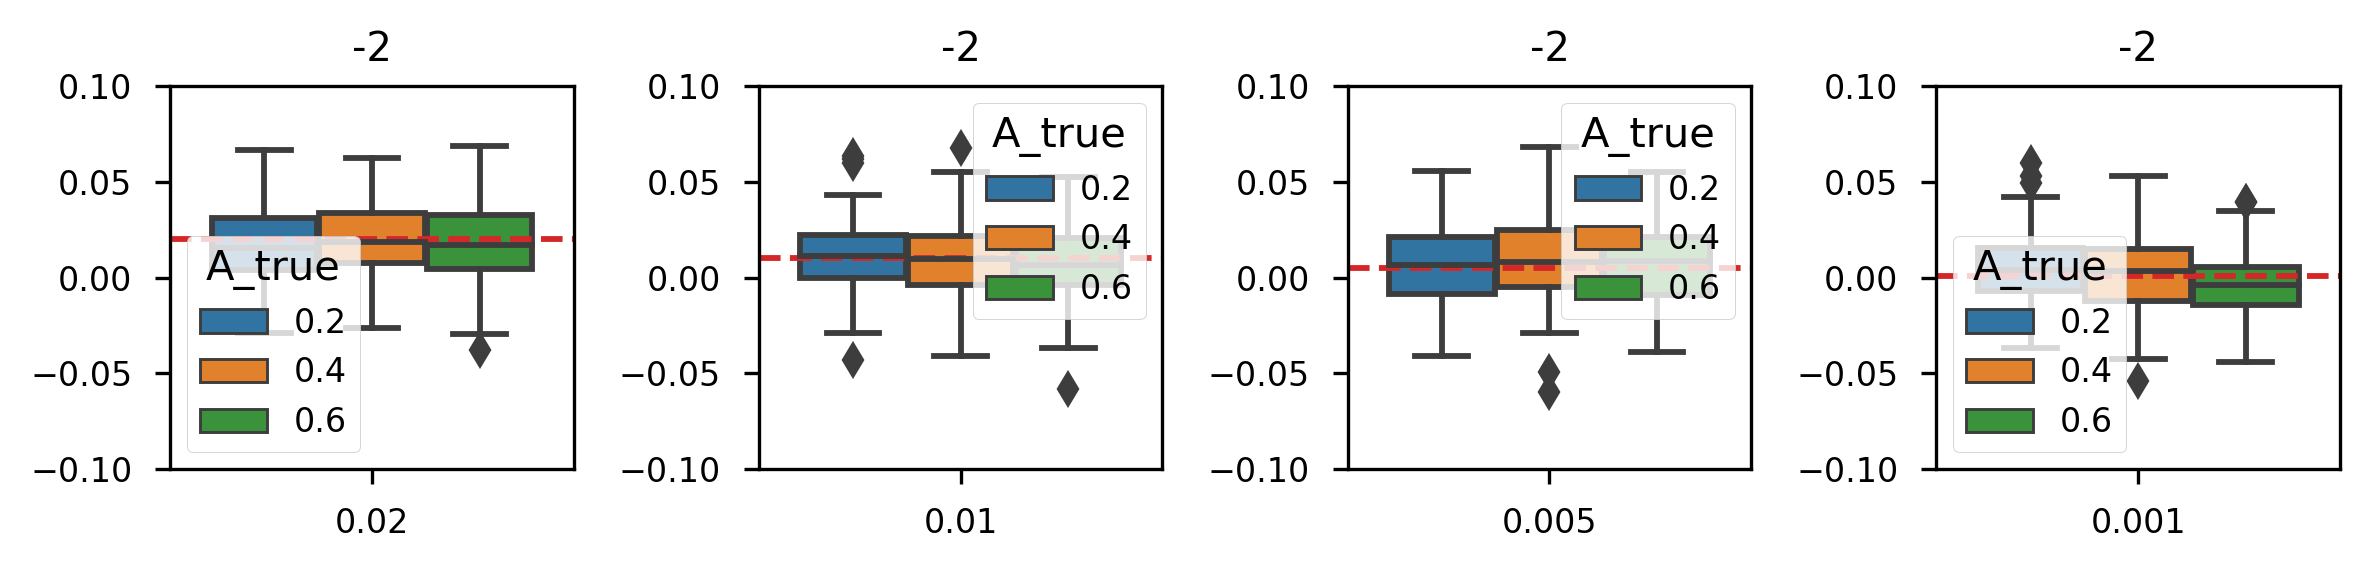

In [ ]:
xtrues = sorted(df_res["X_true"].unique(), reverse=True)
alp = -2
fig, axs = plt.subplots(1, len(xtrues), figsize=(8, 2), dpi=300)

for ci, X_true in enumerate(xtrues):
    ax = axs[ci]
    
    tmp_plot = df_res[(df_res["alp"] == alp) & (df_res["X_true"] == X_true)]
#     # tmp_plot = pd.melt(tmp_plot[["X_true", "X_ridge", "X_noRidge"]],
#     #                 id_vars="X_true")
    # sns.boxplot(data=tmp_plot, #tmp_plot.sort_values(by="variable"),
    #             x="X_true",
    #             y="X_ridge", 
    #             # hue="variable",
    #             ax=ax,
    #             )
    sns.boxplot(data=tmp_plot, #tmp_plot.sort_values(by="variable"),
                x="X_true",
                y="X_noRidge", 
                hue="A_true",
                ax=ax,
                )
    ax.axhline(X_true, ls="--", color="tab:red")
    ax.set_title(alp)
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    ax.set_ylim([-0.1, 0.1])
# sns.despine(offset=0.1, trim=True);

plt.tight_layout();
plt.savefig("/data/jerrylee/pjt/BIGFAM/figures/Xsimulation_variousA2.main.svg", 
            dpi=300, 
            format='svg')

# Step 3. 4 scenarios

In [ ]:
# load reference familial relationships
root_path = "/data/jerrylee/pjt/BIGFAM"
df_frreg = pd.read_csv(f"{root_path}/data/obj2/frreg/Weight.frreg", 
                       delim_whitespace=True)
df_frreg = _matchType(df_frreg)

relations = df_frreg[["DOR", "rel_type", "sex_type", "rx"]]

In [ ]:
def frreg_s1(A, X, Ss, n, noise_sd, df_relations):
    """common"""
    relations = df_relations[["DOR", "rel_type", "sex_type", "rx"]]
    df_lmbds = pd.DataFrame(columns=["DOR", "rel_type", "sex_type", "rx", "slope", "se_slope"])
    
    for _, row in relations.iterrows():
        
        # set true parameters
        dor, rel_type, sex_type, rx = row.values
        ra = 0.5**dor
        rs = np.random.normal(0.5, 0.1)
        S = Ss[dor-1]
        
        lmbd = _make_simul_reg(A, X, S, ra, rx, rs, n=n, noise_sd=0)
        
        df_lmbds.loc[len(df_lmbds)] = [dor, rel_type, sex_type, rx, lmbd, noise_sd]
    
    return df_lmbds

def frreg_s2(A, X, Ss, n, noise_sd, df_relations):
    """1st specific"""
    relations = df_relations[["DOR", "rel_type", "sex_type", "rx"]]
    df_lmbds = pd.DataFrame(columns=["DOR", "rel_type", "sex_type", "rx", "slope", "se_slope"])
    
    for _, row in relations.iterrows():
        
        # set true parameters
        dor, rel_type, sex_type, rx = row.values
        ra = 0.5**dor
        if dor == 1:
            rs = np.random.normal(0.5, 0.1)
        else:
            rs = 0
        S = Ss[dor-1]
        
        lmbd = _make_simul_reg(A, X, S, ra, rx, rs, n=n, noise_sd=0)
        
        df_lmbds.loc[len(df_lmbds)] = [dor, rel_type, sex_type, rx, lmbd, noise_sd]
    
    return df_lmbds

def frreg_s3(A, X, Ss, n, noise_sd, df_relations):
    """maternal specific"""
    relations = df_relations[["DOR", "rel_type", "sex_type", "rx"]]
    df_lmbds = pd.DataFrame(columns=["DOR", "rel_type", "sex_type", "rx", "slope", "se_slope"])
    mother_offspring = ["MS", "MD"]
    for _, row in relations.iterrows():
        
        # set true parameters
        dor, rel_type, sex_type, rx = row.values
        ra = 0.5**dor
        if rel_type in mother_offspring:
            rs = np.random.normal(0.5, 0.1) * 1.5
        else:
            rs = np.random.normal(0.5, 0.1)
        S = Ss[dor-1]
        
        lmbd = _make_simul_reg(A, X, S, ra, rx, rs, n=n, noise_sd=0)
        
        df_lmbds.loc[len(df_lmbds)] = [dor, rel_type, sex_type, rx, lmbd, noise_sd]
        
    return df_lmbds

def frreg_s4(A, X, Ss, n, noise_sd, df_relations):
    """sibling specific"""
    relations = df_relations[["DOR", "rel_type", "sex_type", "rx"]]
    df_lmbds = pd.DataFrame(columns=["DOR", "rel_type", "sex_type", "rx", "slope", "se_slope"])
    sibling = ["SS_DB", "SB", "DS"]
    for _, row in relations.iterrows():
        
        # set true parameters
        dor, rel_type, sex_type, rx = row.values
        ra = 0.5**dor
        if rel_type in sibling:
            rs = np.random.normal(0.5, 0.1) * 1.5
        else:
            rs = np.random.normal(0.5, 0.1)
        S = Ss[dor-1]
        
        lmbd = _make_simul_reg(A, X, S, ra, rx, rs, n=n, noise_sd=0)
        
        df_lmbds.loc[len(df_lmbds)] = [dor, rel_type, sex_type, rx, lmbd, noise_sd]
    
    return df_lmbds

In [ ]:
As = [0.1, 0.3, 0.5]
# As = [0.3]
Ss = [0.2, 0.2/5, 0.2/(5**2)]
n = 1
noise_sd = 5e-3
n_resample = 1
n_block = 1

In [ ]:
df_scenario = pd.DataFrame(columns=["scenario", "alp", "X_true", "X_est"])

for i in tqdm(range(100)):
    for A in As:
        X = A / 20
        dict_frreg = {
            "S1": frreg_s1(A, X, Ss, n, noise_sd, relations),
            "S2": frreg_s2(A, X, Ss, n, noise_sd, relations),
            "S3": frreg_s3(A, X, Ss, n, noise_sd, relations),
            "S4": frreg_s4(A, X, Ss, n, noise_sd, relations),
        }
        
        for scenario in dict_frreg.keys():
            # print(scenario)
            df_frreg = dict_frreg[scenario]
            df_block = _resamplingFRregCoefficients(df_frreg, n_resample, n_block)
            
            # regress out mean
            df_cv = _regressOutMean(df_block)
        
            # RIDGE
            mean_eta = df_cv["eta"].mean()
            alpha = (mean_eta**-2) / df_cv.shape[0]
            
            MODEL = _optToFindX(df_cv, alpha)
            df_scenario.loc[len(df_scenario)] = [scenario, -2, X, MODEL.x[0]]

x_true = 0.015
scenarios = sorted(df_scenario["scenario"].unique())
tmp = df_scenario[(df_scenario["X_true"] == x_true)]

for scenario in scenarios:
    ttmp = tmp[tmp["scenario"] == scenario]
    print(f"{scenario}==========")
    med_nr = np.mean(ttmp["X_est"])
    lower_nr = np.percentile(ttmp["X_est"], 2.5)
    upper_nr = np.percentile(ttmp["X_est"], 97.5)
    print("No Ridge : {med:.3f}({lower:.3f}, {upper:.3f})".
                format(med = med_nr,
                        lower = lower_nr,
                        upper = upper_nr
                        ))


100%|██████████| 100/100 [02:08<00:00,  1.29s/it]

S1==========
No Ridge : 0.011(-0.019, 0.038)
S2==========
No Ridge : 0.010(-0.017, 0.035)
S3==========
No Ridge : 0.021(-0.011, 0.047)
S4==========
No Ridge : 0.018(-0.010, 0.051)


In [ ]:
# df_scenario.to_csv("/data/jerrylee/pjt/BIGFAM/data/obj2/simulation/simulation.scenarios.tsv",
#                    sep='\t',
#                    index=False)

In [ ]:
df_scenario = pd.read_csv("/data/jerrylee/pjt/BIGFAM/data/obj2/simulation/simulation.scenarios.tsv",
                          sep='\t')

In [ ]:
x_true = 0.015
scenarios = sorted(df_scenario["scenario"].unique())
tmp = df_scenario[(df_scenario["X_true"] == x_true)]

for scenario in scenarios:
    ttmp = tmp[tmp["scenario"] == scenario]
    print(f"{scenario}==========")
    med_nr = np.mean(ttmp["X_est"])
    lower_nr = np.percentile(ttmp["X_est"], 2.5)
    upper_nr = np.percentile(ttmp["X_est"], 97.5)
    print("No Ridge : {med:.4f}({lower:.4f}, {upper:.4f})".
                format(med = med_nr,
                        lower = lower_nr,
                        upper = upper_nr
                        ))


S1==========
No Ridge : 0.0109(-0.0186, 0.0377)
S2==========
No Ridge : 0.0097(-0.0169, 0.0354)
S3==========
No Ridge : 0.0210(-0.0110, 0.0474)
S4==========
No Ridge : 0.0178(-0.0097, 0.0505)


## Step 3.1 plot

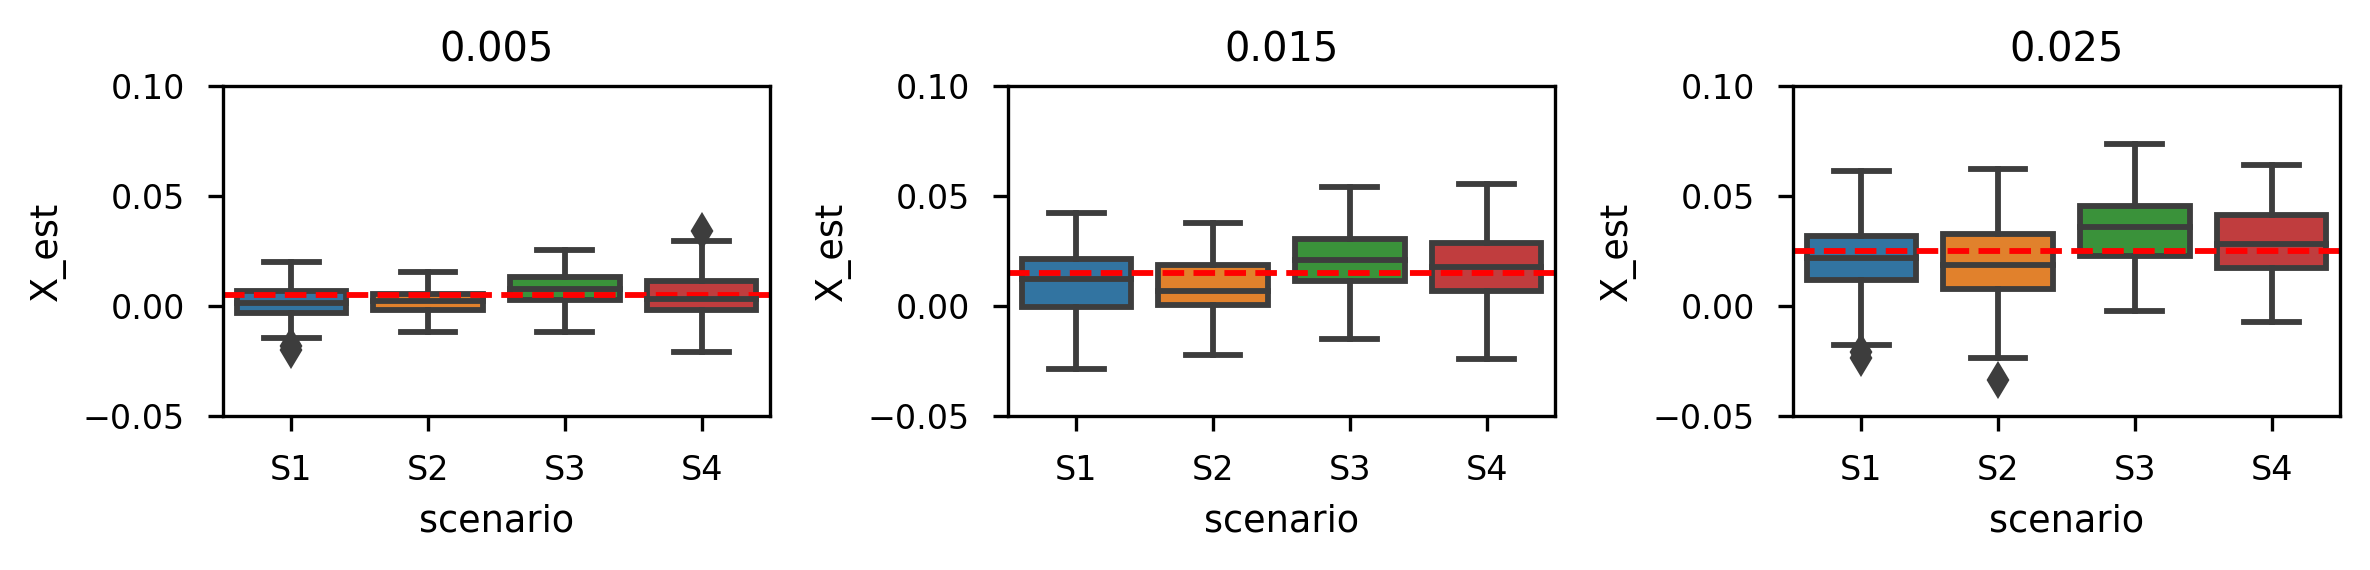

In [ ]:
Xs = df_scenario["X_true"].unique()
fig, axs = plt.subplots(1, len(Xs), figsize=(8, 2), dpi=300)

for ci, x_true in enumerate(Xs):
    # for ri, alp in enumerate(alps):
        # tmp = df_scenario[(df_scenario["alp"] == alp) & ((df_scenario["X_true"] == x_true))]
        tmp = df_scenario[(df_scenario["X_true"] == x_true)]
        # ax = axs[ri, ci]
        ax = axs[ci]
        
        sns.boxplot(data=tmp,
            x="scenario",
            y="X_est",
            ax=ax)
        ax.axhline(x_true, color="red", ls="--")
        ax.set_title(f"{x_true}")
        ax.set_ylim([-0.05, 0.10])

plt.tight_layout();
plt.savefig("/data/jerrylee/pjt/BIGFAM/figures/Xsimulation_scenarios.svg", 
            dpi=300, 
            format='svg')